# L2C - Du plan aux dessins d'atelier : exploration et démonstration

This notebook walks through the pipeline end to end on one project.

It runs on a **synthetic project** (`l2c_rebar.synthetic`) so that no confidential drawing content is stored in the notebook outputs. To run it on a real project, set `PROJECT` in the next cell to the project folder and re-run everything locally.

In [1]:
from pathlib import Path
import json, tempfile
import pymupdf, pandas as pd
from l2c_rebar.synthetic import build_project, PLANTED

WORK = Path(tempfile.mkdtemp(prefix='l2c_demo_'))
PROJECT = build_project(WORK)          # or: Path('C:/path/to/a/real/project')
OUT = WORK / 'out'
PROJECT

WindowsPath('C:/Users/rkiae/AppData/Local/Temp/l2c_demo_7r2a59ud/DEMO')

## 1. Data exploration

A project is one plan PDF at its root and shop drawings (`DA/`) grouped by element type. The first question for every page: does it carry real text, or only drawn strokes that need OCR?

In [2]:
from l2c_rebar.pipeline import discover, shop_file_hints

files = discover(PROJECT)
rows = []
for path in files.plans + files.shops:
    with pymupdf.open(path) as doc:
        words = [len(p.get_text('words')) for p in doc]
        hint = ('plan', ()) if path in files.plans else shop_file_hints(path, files.root)
        rows.append({'fichier': path.name, 'pages': doc.page_count, 'mots': sum(words),
                     'pages_sans_texte': sum(w < 25 for w in words), 'type': hint[0], 'niveaux': hint[1]})
pd.DataFrame(rows)

,fichier,pages,mots,pages_sans_texte,type,niveaux
0,L2C_PLAN_STR_DEMO.pdf,5,191,1,plan,()
1,DEMO_COLONNE-NIV-2@3.pdf,1,45,0,colonne,"(2, 3)"
2,DEMO_COLONNE-NIV-RDC@2.pdf,1,28,0,colonne,"(RDC, 2)"
3,DEMO_DALLE NIV 2.pdf,1,25,0,dalle,"(2,)"
4,DEMO_SEMELLES.pdf,1,29,0,fondation,()
5,DEMO_MURS REFENDS.pdf,1,31,0,mur de refend,()
6,DEMO_POUTRES.pdf,1,37,0,poutre,()


Text lines come out in *displayed* page coordinates (top-left origin, PDF points), which is what Appendix A asks for.

In [3]:
from l2c_rebar.pdf.text import text_layer_lines

with pymupdf.open(files.plans[0]) as doc:
    lines = text_layer_lines(doc[3])
pd.DataFrame([{'texte': l.text, 'x': round((l.bbox[0]+l.bbox[2])/2, 1), 'y': round((l.bbox[1]+l.bbox[3])/2, 1)} for l in lines]).head(12)

,texte,x,y
0,COLONNES - TABLEAU DES COLONNES,1040.1,697.7
1,S-501,963.3,743.5
2,C1,257.0,115.7
3,C2,407.0,115.7
4,C3,557.0,115.7
5,C4,707.0,115.7
6,NIV. 3,93.9,196.1
7,6-20M,247.8,196.5
8,LIG. 10M @ 300,268.1,210.5
9,6-20M,397.8,196.5


## 2. Reading a callout

The grammar covers the notations met on plans and shop drawings, metric or imperial spacing.

In [4]:
from l2c_rebar.parsing.rebar import find_bars

samples = ['VERT.: 8-25M', 'LIG.: 10M@300 c/c', 'LIG.: 10M@12" c/c', '12(6)-15M',
           'T: 24 15M 15A12 @12"', 'B: 24 15M 20-6', '8-20M x 3000 SUP.']
pd.DataFrame([{'texte': s, **{k: getattr(b, k) for k in ('quantite', 'diametre', 'espacement_mm', 'longueur_mm', 'repere', 'role')}}
              for s in samples for b in find_bars(s)])

,texte,quantite,diametre,espacement_mm,longueur_mm,repere,role
0,VERT.: 8-25M,8.0,25M,NaN,NaN,NaN,vert
1,LIG.: 10M@300 c/c,NaN,10M,300.0,NaN,NaN,ligature
2,"LIG.: 10M@12"" c/c",NaN,10M,305.0,NaN,NaN,ligature
3,12(6)-15M,12.0,15M,NaN,NaN,NaN,NaN
4,"T: 24 15M 15A12 @12""",24.0,15M,305.0,NaN,15A12,sup
5,B: 24 15M 20-6,24.0,15M,NaN,6248.0,NaN,inf
6,8-20M x 3000 SUP.,8.0,20M,NaN,3000.0,NaN,sup


## 3. Full pipeline: extract, build the JSON database, compare

In [5]:
from l2c_rebar.config import Config
from l2c_rebar.pipeline import run_project

out = run_project(PROJECT, OUT, Config(ocr='auto'))
{k: v for k, v in out.stats.items() if k != 'par_type'}

{'plan_pages': 5,
 'plan_pages_ocr': 1,
 'plan_pages_vides': 0,
 'atelier_pages': 6,
 'atelier_pages_ocr': 0,
 'atelier_pages_vides': 0,
 'plan_elements': 25,
 'atelier_elements': 21,
 'plan_barres': 47,
 'atelier_barres': 40,
 'plan_reperes': 21,
 'atelier_reperes': 17,
 'reperes_communs': 13,
 'feuillets': 5,
 'conforme': 15,
 'non_conforme': 5,
 'manquant_atelier': 1,
 'ajoute_atelier': 1,
 'a_valider': 4,
 'apparies_par_repere': 17,
 'duree_s': 9.3}

In [6]:
pd.DataFrame(out.stats['par_type']).T.fillna(0).astype(int)

,plan_pages,atelier_pages,atelier_pages_ocr,plan_elements,plan_reperes,plan_barres,atelier_elements,atelier_reperes,atelier_barres,reperes_communs,non_conforme,par_repere,manquant_atelier,ajoute_atelier,conforme
colonne,1,2,0,12,12,24,8,8,16,4,1,8,1,1,6
dalle,1,1,0,4,0,4,4,0,5,0,1,0,0,0,3
fondation,1,1,0,4,4,4,4,4,4,4,1,4,0,0,3
mur de refend,1,1,0,2,2,6,2,2,6,2,1,2,0,0,1
poutre,1,1,0,3,3,9,3,3,9,3,1,3,0,0,2


The JSON database follows Appendix A exactly (validated with pydantic):

In [7]:
records = json.loads(out.files['elements'].read_text(encoding='utf-8'))
print(len(records), 'records')
print(json.dumps(next(r for r in records if r['element'] == 'C3' and r['source'] == 'plan'), indent=2, ensure_ascii=False))

46 records
{
  "id": "S-501_C3@3_plan",
  "source": "plan",
  "fichier": "L2C_PLAN_STR_DEMO.pdf",
  "feuillet": "S-501",
  "page": 4,
  "x": 557.0,
  "y": 115.7,
  "type_element": "colonne",
  "element": "C3",
  "armature": [
    {
      "repere": null,
      "diametre": "20M",
      "quantite": 6,
      "espacement_mm": null,
      "longueur_mm": null
    },
    {
      "repere": null,
      "diametre": "10M",
      "quantite": null,
      "espacement_mm": 300,
      "longueur_mm": null
    }
  ]
}


## 4. Findings

Each element is classified: compliant, non-compliant (with the discrepancy), missing from the shop drawings, or added in the shop drawings.

In [8]:
from l2c_rebar.compare import summarize

pd.DataFrame(summarize(out.results)).T

,conforme,non_conforme,manquant_atelier,ajoute_atelier,a_valider
S-101,3,1,0,0,0
S-301,2,1,0,0,0
S-401,1,1,0,0,0
S-501,6,1,1,1,0
S-601,3,1,0,0,4


In [9]:
pd.DataFrame([{'id': r.id, 'feuillet': r.feuillet, 'type': r.type_element, 'element': r.element, 'statut': r.statut,
               'gravite': r.gravite if r.ecarts else '', 'confiance': r.confiance, 'ecart': ' ; '.join(e.message for e in r.ecarts)}
              for r in out.results if r.statut != 'conforme'])

,id,feuillet,type,element,statut,gravite,confiance,ecart
0,NC-0001,S-101,fondation,S3,non_conforme,critique,0.95,"Quantité : plan 8 barres 20M, atelier 6 (manqu..."
1,NC-0002,S-301,poutre,P2,non_conforme,critique,0.93,"Espacement : plan 10M @ 200 mm, atelier @ 250 ..."
2,NC-0003,S-401,mur de refend,MR2,non_conforme,critique,0.92,"Diamètre : plan 25M, atelier 20M (plus petit)"
3,NC-0004,S-501,colonne,C3,non_conforme,critique,0.93,"Quantité : plan 8 barres 25M, atelier 6 (manqu..."
4,MQ-0001,S-501,colonne,C4,manquant_atelier,,0.65,
5,AJ-0001,S-501,colonne,C9,ajoute_atelier,,0.66,
6,NC-0005,S-601,dalle,ZONE-D2-01,non_conforme,critique,0.38,"Quantité : plan 10 barres 20M, atelier 8 (manq..."


The synthetic project plants five discrepancies; all five must be found, with no false alarm:

In [10]:
found = {(r.type_element, e.attribut, e.plan, e.atelier) for r in out.results for e in r.ecarts}
pd.DataFrame([{**p, 'detecte': (p['type'], p['attribut'], p['plan'], p['atelier']) in found} for p in PLANTED])

,element,type,attribut,plan,atelier,detecte
0,S3,fondation,quantite,8,6,True
1,P2,poutre,espacement_mm,200,250,True
2,MR2,mur de refend,diametre,25M,20M,True
3,C3,colonne,quantite,8,6,True
4,dalle,dalle,quantite,10,8,True


## 5. PDF report and annotated PDFs

The report opens with counts per plan sheet, then one list of every non-conformity and missing element, by sheet and grid place (`axes B-12`), then a detailed card per finding with image extracts of both drawings.

In [11]:
from l2c_rebar.report.pdf_report import build_report
from l2c_rebar.report.annotate import annotate_project

report = build_report(out.project, out.results, out.coverage, out.stats, OUT / 'rapport.pdf', Config())
annotated = annotate_project(out.results, OUT)
print(report.name, '+', len(annotated), 'annotated PDFs')

rapport.pdf + 7 annotated PDFs


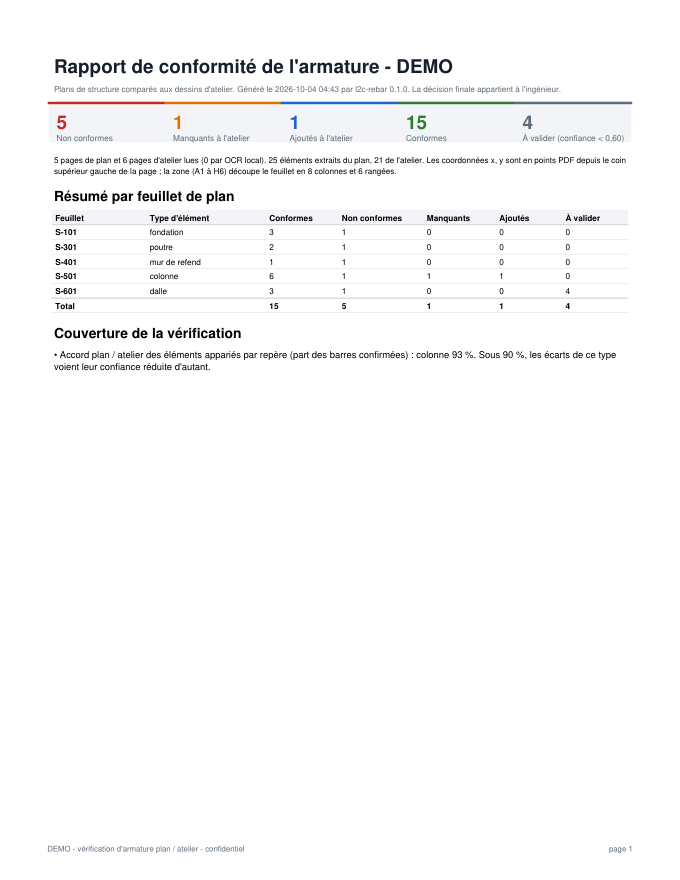

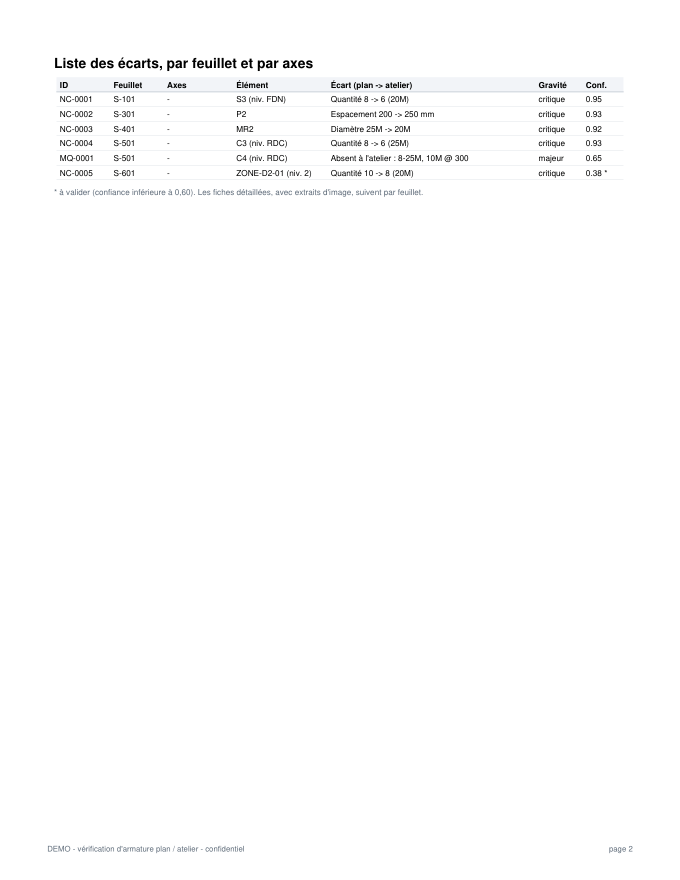

In [12]:
from IPython.display import Image, display

with pymupdf.open(report) as doc:
    for i in (0, 1):
        display(Image(data=doc[i].get_pixmap(dpi=80).tobytes('png')))

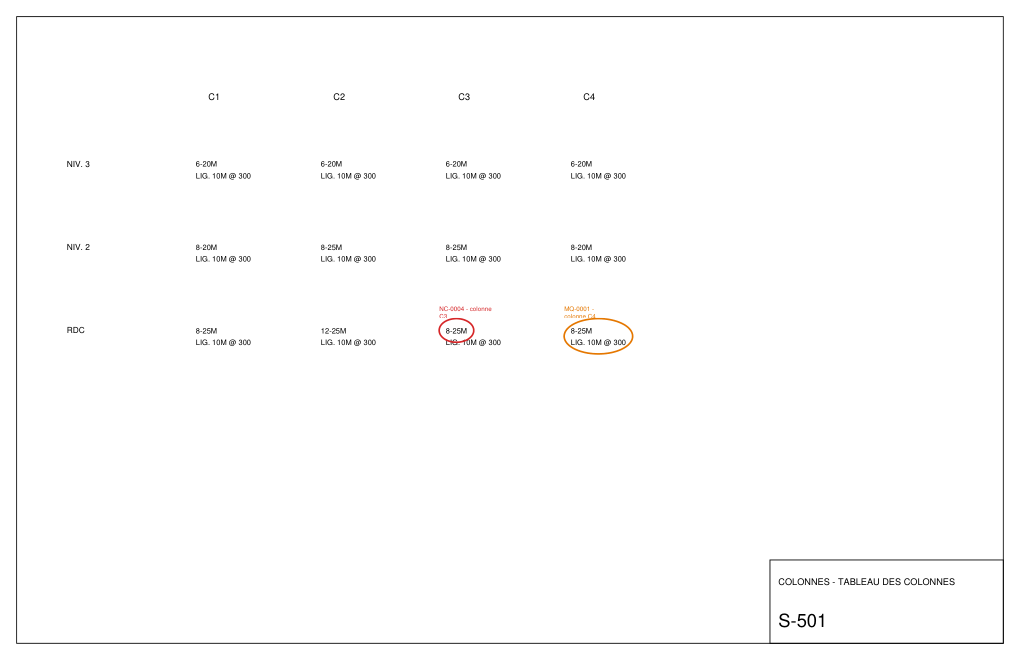

In [13]:
plan = next(p for src, p in annotated.items() if 'PLAN' in src)
with pymupdf.open(plan) as doc:
    display(Image(data=doc[3].get_pixmap(dpi=60).tobytes('png')))

## 6. Columns located by their place on the grid

On a column plan a column has no name: it is a filled rectangle at a grid crossing, with a tag beside it. The grid is rebuilt from its bubbles, each tag is paired with its rectangle, and the column is named by its crossing (`B-3`), which is how shop drawings refer to it. A second made-up project shows this.

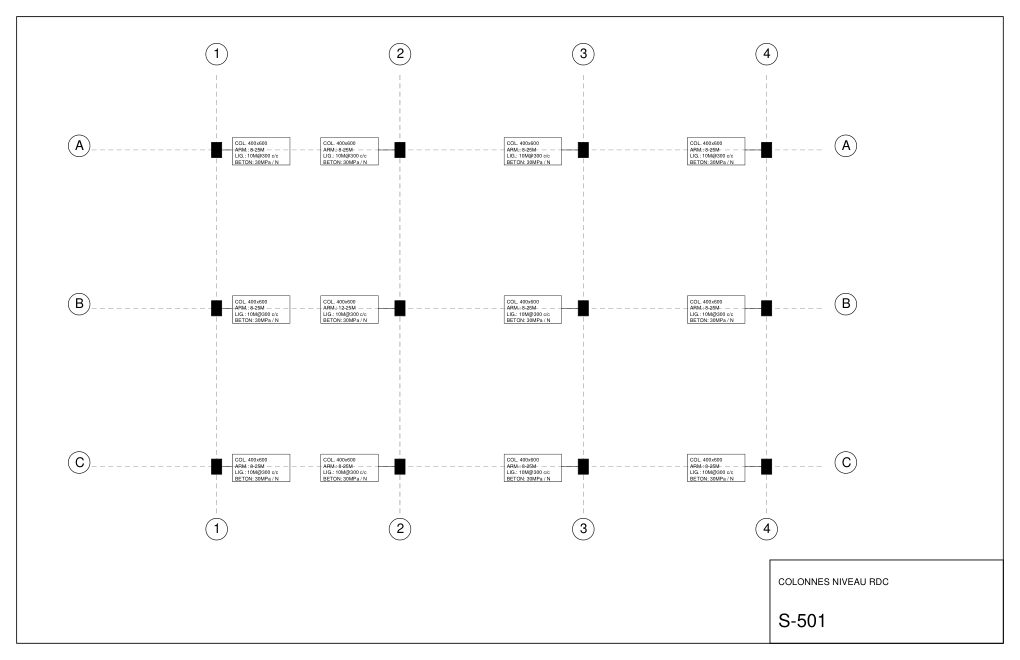

In [14]:
from l2c_rebar.synthetic import build_grid_project, write_known_list, GRID_PLANTED

GRID = build_grid_project(WORK)
with pymupdf.open(discover(GRID).plans[0]) as doc:
    display(Image(data=doc[0].get_pixmap(dpi=60).tobytes('png')))

In [15]:
grid_out = run_project(GRID, WORK / 'out_grid', Config(ocr='off'))
pd.DataFrame([{'feuillet': e.feuillet, 'colonne': e.element, 'niveau': e.levels, 'x': round(e.x), 'y': round(e.y),
               'armature': [b.describe() for b in e.bars]} for e in grid_out.plan_elements[:8]])

,feuillet,colonne,niveau,x,y,armature
0,S-501,A-1,"(RDC,)",311,183,"[8-25M, 10M @ 300]"
1,S-501,A-2,"(RDC,)",417,183,"[8-25M, 10M @ 300]"
2,S-501,A-3,"(RDC,)",637,183,"[8-25M, 10M @ 300]"
3,S-501,A-4,"(RDC,)",857,183,"[8-25M, 10M @ 300]"
4,S-501,B-1,"(RDC,)",311,373,"[8-25M, 10M @ 300]"
5,S-501,B-2,"(RDC,)",417,373,"[12-25M, 10M @ 300]"
6,S-501,B-3,"(RDC,)",637,373,"[8-25M, 10M @ 300]"
7,S-501,B-4,"(RDC,)",857,373,"[8-25M, 10M @ 300]"


The shop drawings name storeys their own way (`RDC@2`, `2@3`) and draw one detail for two identical columns, with totals. Both are resolved by keeping the reading that agrees most often with the plan.

In [16]:
print(grid_out.coverage.level_shift, grid_out.coverage.lecture)
pd.DataFrame([{'id': r.id, 'feuillet': r.feuillet, 'colonne': r.element, 'statut': r.statut, 'gravite': r.gravite if r.ecarts else '',
               'ecart': ' ; '.join(e.message for e in r.ecarts), 'note': r.note}
              for r in grid_out.results if r.statut != 'conforme' or r.note])

{'colonne': {'niveaux_atelier': 2, 'renommes': 0}} {'colonne': 'details'}


,id,feuillet,colonne,statut,gravite,ecart,note
0,NC-0001,S-501,B-4,non_conforme,critique,"Espacement : plan 10M @ 300 mm, atelier @ 400 ...",
1,NC-0002,S-501,C-3,non_conforme,critique,"Quantité : plan 8 barres 25M, atelier 6 (manqu...",
2,OK-0009,S-501,A-2,conforme,,,Quantité d'atelier multiple de celle du plan :...
3,OK-0010,S-501,A-3,conforme,,,Quantité d'atelier multiple de celle du plan :...
4,NC-0003,S-502,A-4,non_conforme,critique,"Diamètre : plan 25M, atelier 20M (plus petit)",
5,OK-0020,S-502,B-3,conforme,,,Quantité d'atelier multiple de celle du plan :...
6,OK-0021,S-502,B-4,conforme,,,Quantité d'atelier multiple de celle du plan :...


### Scoring a run against documented non-conformities

The jury holds a list of known non-conformities: sheet, grid location, what the plan says, what the shop drawing says. `evaluate` scores a run against such a list and says, for each miss, at which stage it was lost.

In [17]:
from l2c_rebar.evaluate import axes_of_plan, load_known, score_run, summarize_scores
from l2c_rebar.extract.document import read_document

known = load_known(write_known_list(WORK / 'known.xlsx', GRID_PLANTED))
pages, _ = read_document(discover(GRID).plans[0], 'plan', Config(ocr='off'), None)
summarize_scores(score_run(known, grid_out.plan_elements, grid_out.results, axes_of_plan(pages)))

{'connues': 3,
 'feuillet_lu': 3,
 'valeur_plan_extraite': 3,
 'valeur_plan_au_bon_endroit': 3,
 'signalees': 3,
 'memes_valeurs': 3}

## 7. Same thing from the command line

```
python -m l2c_rebar run <project folder>               # JSON + PDF report + annotated PDFs
python -m l2c_rebar run <project folder> --fast        # live demonstration: OCR at 200 dpi, no image extracts
python -m l2c_rebar evaluate <project folder> known.xlsx  # score against documented non-conformities
python -m l2c_rebar ui                                 # interface with validation of uncertain cases
python -m l2c_rebar diff old.pdf new.pdf               # what changed between two revisions
```